<a href="https://colab.research.google.com/github/DineshMohapatr/NMT-System-HuggingFace/blob/main/NMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Machine Translation (NMT) System using Hugging Face Transformers

## Objectives

1.  **Implement an NMT System**: Utilize Hugging Face Transformers to build a functional NMT system.
2.  **Model Comparison**: Compare the performance of two distinct translation models (MarianMT and NLLB-200).
3.  **Interactive Interface**: Develop a Gradio-based interactive translation system with configurable parameters.
4.  **Performance Evaluation**: Measure and compare translation quality (BLEU score), speed, and memory consumption.
5.  **Experimental Analysis**: Evaluate models on news articles, technical paragraphs, and conversational text.
6.  **Visualization**: Create plots to visually represent comparison metrics.
7.  **Detailed Analysis**: Provide observations on model strengths, weaknesses, and a comprehensive conclusion.

In [1]:
# Install required libraries
!pip install transformers sentencepiece sacrebleu evaluate gradio torch pandas matplotlib psutil -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00


In [2]:
import torch
import pandas as pd
import time
import psutil
import os
import sacrebleu
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, MarianMTModel, MarianTokenizer
import evaluate
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Language mappings for NLLB-200
nllb_lang_map = {
    'en': 'eng_Latn',
    'fr': 'fra_Latn',
    'hi': 'hin_Deva'
}

def load_model(model_name):
    """Loads a Hugging Face translation model and its tokenizer."""
    print(f"Loading model: {model_name}...")
    try:
        if "opus-mt" in model_name:
            tokenizer = MarianTokenizer.from_pretrained(model_name)
            model = MarianMTModel.from_pretrained(model_name)
        elif "nllb-200" in model_name:
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        else:
            raise ValueError("Unsupported model type.")
        print(f"Model {model_name} loaded successfully.")
        return tokenizer, model
    except Exception as e:
        print(f"Error loading {model_name}: {e}")
        return None, None

# Load MarianMT model (English to French)
marian_tokenizer_en_fr, marian_model_en_fr = load_model("Helsinki-NLP/opus-mt-en-fr")

# Load NLLB-200 model
nllb_tokenizer, nllb_model = load_model("facebook/nllb-200-distilled-600M")

Loading model: Helsinki-NLP/opus-mt-en-fr...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model facebook/nllb-200-distilled-600M loaded successfully.


## Reusable Functions

We will define several reusable functions to handle translation, BLEU score evaluation, and model comparison. These functions will ensure modularity and reusability throughout the notebook.

In [4]:
def translate_text(text, source_lang, target_lang, model_choice, max_length, num_beams, length_penalty, temperature, top_k, top_p):
    """Translates text using the chosen model and parameters."""
    if not text:
        return "Error: Input text cannot be empty."
    if source_lang == target_lang:
        return "Error: Source and target languages cannot be the same."
    if len(text) > 1000:
        return "Error: Text length restricted to 1000 characters."

    if model_choice == "MarianMT (en-fr)":
        if source_lang != 'en' or target_lang != 'fr':
            return "Error: MarianMT (en-fr) only supports English to French translation."
        tokenizer, model = marian_tokenizer_en_fr, marian_model_en_fr
        if tokenizer is None or model is None:
            return "Error: MarianMT model not loaded."

        # Prepare input for MarianMT
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        translated_tokens = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            length_penalty=length_penalty,
            temperature=temperature,
            top_k=int(top_k) if top_k > 0 else None, # top_k must be int or None
            top_p=top_p
        )
        return tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

    elif model_choice == "NLLB-200":
        if nllb_tokenizer is None or nllb_model is None:
            return "Error: NLLB-200 model not loaded."

        src_lang_code = nllb_lang_map.get(source_lang)
        tgt_lang_code = nllb_lang_map.get(target_lang)

        if not src_lang_code:
            return f"Error: NLLB-200 does not support source language '{source_lang}'."
        if not tgt_lang_code:
            return f"Error: NLLB-200 does not support target language '{target_lang}'."

        nllb_tokenizer.src_lang = src_lang_code
        inputs = nllb_tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        translated_tokens = nllb_model.generate(
            **inputs,
            forced_bos_token_id=nllb_tokenizer.convert_tokens_to_ids(tgt_lang_code),
            max_length=max_length,
            num_beams=num_beams,
            length_penalty=length_penalty,
            temperature=temperature,
            top_k=int(top_k) if top_k > 0 else None,
            top_p=top_p
        )
        return nllb_tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

    else:
        return "Error: Invalid model choice."

def evaluate_bleu(predictions, references):
    """Calculates the BLEU score for given predictions and references."""
    # sacrebleu expects references as a list of lists of strings
    if not isinstance(references[0], list):
        references = [[ref] for ref in references]
    bleu = sacrebleu.corpus_bleu(predictions, references)
    return bleu.score

def get_memory_usage():
    """Returns current memory usage in MB."""
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / (1024 * 1024) # in MB

def compare_models(text, source_lang, target_lang, max_length, num_beams, length_penalty, temperature, top_k, top_p, model_choices=None):
    """Compares two models based on speed, memory, and translates the text."""
    if model_choices is None:
        model_choices = ["MarianMT (en-fr)", "NLLB-200"]

    results = []

    for model_choice in model_choices:
        start_mem = get_memory_usage()
        start_time = time.time()

        translated_text = translate_text(text, source_lang, target_lang, model_choice, max_length, num_beams, length_penalty, temperature, top_k, top_p)

        end_time = time.time()
        end_mem = get_memory_usage()

        speed = end_time - start_time
        memory_used = end_mem - start_mem # Change in memory usage

        # Placeholder for translation quality, long sentence handling, multilingual support
        # These will be evaluated qualitatively or through specific tests later.
        quality_placeholder = "To be evaluated"
        long_sentence_handling = "Good" if len(text) > 50 else "N/A"
        if model_choice == "MarianMT (en-fr)":
            multilingual_support = "Limited (en-fr only)"
        else:
            multilingual_support = "Extensive (many languages)"

        results.append({
            "Model": model_choice,
            "Translated Text": translated_text,
            "Speed (seconds)": f"{speed:.4f}",
            "Memory Usage (MB)": f"{memory_used:.2f}",
            "Long Sentence Handling": long_sentence_handling,
            "Multilingual Support": multilingual_support
        })
    return pd.DataFrame(results)

## Interactive Translation System

We will build an interactive translation system using Gradio. This interface will allow users to input text, select source and target languages, choose a model, and configure various translation parameters. Input validation will be implemented to ensure a robust user experience.

In [5]:
def gradio_translate(text, source_lang, target_lang, model_choice, max_length, num_beams, length_penalty, temperature, top_k, top_p):
    """Wrapper function for Gradio interface to call translate_text and handle errors."""
    # Ensure top_k is an integer for the backend function
    top_k_int = int(top_k) if top_k > 0 else 0
    return translate_text(text, source_lang, target_lang, model_choice, max_length, num_beams, length_penalty, temperature, top_k_int, top_p)

# Gradio interface definition
iface = gr.Interface(
    fn=gradio_translate,
    inputs=[
        gr.Textbox(lines=5, label="Input Text", placeholder="Enter text to translate (max 1000 chars)"),
        gr.Dropdown(["en", "fr", "hi"], label="Source Language", value="en"),
        gr.Dropdown(["en", "fr", "hi"], label="Target Language", value="fr"),
        gr.Radio(["MarianMT (en-fr)", "NLLB-200"], label="Select Model", value="NLLB-200"),
        gr.Slider(minimum=10, maximum=200, value=50, step=1, label="Max Length (translation output)"),
        gr.Slider(minimum=1, maximum=10, value=4, step=1, label="Num Beams"),
        gr.Slider(minimum=-2.0, maximum=2.0, value=1.0, step=0.1, label="Length Penalty"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.7, step=0.05, label="Temperature"),
        gr.Slider(minimum=0, maximum=100, value=0, step=1, label="Top K (0 for disabled)"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.9, step=0.05, label="Top P")
    ],
    outputs=gr.Textbox(label="Translated Output", lines=5),
    title="Neural Machine Translation System",
    description="Translate text using MarianMT or NLLB-200 models with configurable parameters."
)

# Launch Gradio interface
iface.launch(share=True) # Uncommented to launch and get a shareable link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc52401ec17eef8e41.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Note on Gradio Launch:

To interact with the Gradio interface, please uncomment `iface.launch(share=True)` in the previous cell and run it. This will provide a local and a public URL (if `share=True`) to access the GUI.

## Model Comparison

We will compare the two models based on translation quality, speed, memory usage, ability to handle long sentences, and multilingual support. A pandas DataFrame will be used to present the comparison results.

In [6]:
# Example text for comparison
text_to_compare = "The quick brown fox jumps over the lazy dog. This is a moderately long sentence to test translation capabilities and performance." # English

# Define common translation parameters for comparison
comparison_params = {
    "max_length": 100,
    "num_beams": 5,
    "length_penalty": 1.0,
    "temperature": 0.7,
    "top_k": 0,
    "top_p": 0.9
}

# Perform comparison for en-fr
print("Comparing models for English to French translation...")
en_fr_comparison_df = compare_models(
    text=text_to_compare,
    source_lang="en",
    target_lang="fr",
    **comparison_params,
    model_choices=["MarianMT (en-fr)", "NLLB-200"]
)
display(en_fr_comparison_df)

# Perform comparison for en-hi (only NLLB supports this here)
print("\nComparing NLLB-200 for English to Hindi translation...")
en_hi_comparison_df = compare_models(
    text="Hello, how are you?",
    source_lang="en",
    target_lang="hi",
    **comparison_params,
    model_choices=["NLLB-200"]
)
display(en_hi_comparison_df)

# Combine results for further analysis if needed
combined_comparison_df = pd.concat([en_fr_comparison_df, en_hi_comparison_df], ignore_index=True)
print("\nCombined comparison data:")
display(combined_comparison_df)

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Comparing models for English to French translation...


,Model,Translated Text,Speed (seconds),Memory Usage (MB),Long Sentence Handling,Multilingual Support
0,MarianMT (en-fr),Le renard brun rapide saute sur le chien pares...,5.4251,-194.69,Good,Limited (en-fr only)
1,NLLB-200,Le renard brun rapide saute sur le chien pares...,19.9068,623.33,Good,Extensive (many languages)



Comparing NLLB-200 for English to Hindi translation...


,Model,Translated Text,Speed (seconds),Memory Usage (MB),Long Sentence Handling,Multilingual Support
0,NLLB-200,"हैलो, आप कैसे हैं?",3.0624,38.97,N/A,Extensive (many languages)



Combined comparison data:


,Model,Translated Text,Speed (seconds),Memory Usage (MB),Long Sentence Handling,Multilingual Support
0,MarianMT (en-fr),Le renard brun rapide saute sur le chien pares...,5.4251,-194.69,Good,Limited (en-fr only)
1,NLLB-200,Le renard brun rapide saute sur le chien pares...,19.9068,623.33,Good,Extensive (many languages)
2,NLLB-200,"हैलो, आप कैसे हैं?",3.0624,38.97,N/A,Extensive (many languages)


## BLEU Score Evaluation

The Bilingual Evaluation Understudy (BLEU) score is a widely used metric for evaluating the quality of machine-translated text. We will calculate BLEU scores for both models using `sacrebleu` by translating a set of English sentences into French and comparing them against human references.

In [7]:
# Sample data for BLEU score evaluation (English to French)
source_texts = [
    "Global markets showed positive growth after the announcement of new economic policies.",
    "Deep learning models require large datasets and computational resources for training.",
    "Hello, how are you today? I hope you are doing well.",
    "The cat sat on the mat."
]

reference_translations_fr = [
    "Les marchés mondiaux ont montré une croissance positive après l'annonce de nouvelles politiques économiques.",
    "Les modèles d'apprentissage profond nécessitent de grands ensembles de données et des ressources de calcul pour l'entraînement.",
    "Bonjour, comment allez-vous aujourd'hui ? J'espère que vous allez bien.",
    "Le chat était assis sur le tapis."
]

bleu_results = []

# Evaluate MarianMT (en-fr)
if marian_model_en_fr and marian_tokenizer_en_fr:
    marian_predictions = []
    for text in source_texts:
        # Using default parameters suitable for quality evaluation
        translated = translate_text(text, 'en', 'fr', "MarianMT (en-fr)", max_length=100, num_beams=5, length_penalty=1.0, temperature=0.7, top_k=0, top_p=0.9)
        marian_predictions.append(translated)
    marian_bleu = evaluate_bleu(marian_predictions, reference_translations_fr)
    bleu_results.append({"Model": "MarianMT (en-fr)", "BLEU Score": marian_bleu})
    print(f"MarianMT (en-fr) BLEU Score: {marian_bleu:.2f}")

# Evaluate NLLB-200 (en-fr)
if nllb_model and nllb_tokenizer:
    nllb_predictions = []
    for text in source_texts:
        translated = translate_text(text, 'en', 'fr', "NLLB-200", max_length=100, num_beams=5, length_penalty=1.0, temperature=0.7, top_k=0, top_p=0.9)
        nllb_predictions.append(translated)
    nllb_bleu = evaluate_bleu(nllb_predictions, reference_translations_fr)
    bleu_results.append({"Model": "NLLB-200", "BLEU Score": nllb_bleu})
    print(f"NLLB-200 (en-fr) BLEU Score: {nllb_bleu:.2f}")

bleu_df = pd.DataFrame(bleu_results)
display(bleu_df)

MarianMT (en-fr) BLEU Score: 80.03
NLLB-200 (en-fr) BLEU Score: 80.03


,Model,BLEU Score
0,MarianMT (en-fr),80.032032
1,NLLB-200,80.032032


## Experimental Analysis

We will translate and evaluate specific text types (news, technical, conversational) using both MarianMT and NLLB-200. This will provide insights into how each model handles different linguistic styles and domains. BLEU scores will be computed for French translations.

In [8]:
experimental_texts = {
    "News Article": {
        "text": "Global markets showed positive growth after the announcement of new economic policies.",
        "reference_fr": "Les marchés mondiaux ont montré une croissance positive après l'annonce de nouvelles politiques économiques."
    },
    "Technical Paragraph": {
        "text": "Deep learning models require large datasets and computational resources for training.",
        "reference_fr": "Les modèles d'apprentissage profond nécessitent de grands ensembles de données et des ressources de calcul pour l'entraînement."
    },
    "Conversational Text": {
        "text": "Hello, how are you today? I hope you are doing well.",
        "reference_fr": "Bonjour, comment allez-vous aujourd'hui ? J'espère que vous allez bien."
    }
}

experimental_results = []

for text_type, data in experimental_texts.items():
    input_text = data["text"]
    reference_fr = data["reference_fr"]

    print(f"\n--- Evaluating: {text_type} ---")
    print(f"Input: {input_text}")

    # MarianMT
    if marian_model_en_fr and marian_tokenizer_en_fr:
        marian_translated_fr = translate_text(input_text, 'en', 'fr', "MarianMT (en-fr)", max_length=100, num_beams=5, length_penalty=1.0, temperature=0.7, top_k=0, top_p=0.9)
        marian_bleu = evaluate_bleu([marian_translated_fr], [reference_fr])
        experimental_results.append({
            "Text Type": text_type,
            "Model": "MarianMT (en-fr)",
            "Source Text": input_text,
            "Translated Text": marian_translated_fr,
            "Reference (FR)": reference_fr,
            "BLEU Score": f"{marian_bleu:.2f}"
        })
        print(f"MarianMT Translated (FR): {marian_translated_fr}")
        print(f"MarianMT BLEU Score: {marian_bleu:.2f}")

    # NLLB-200
    if nllb_model and nllb_tokenizer:
        nllb_translated_fr = translate_text(input_text, 'en', 'fr', "NLLB-200", max_length=100, num_beams=5, length_penalty=1.0, temperature=0.7, top_k=0, top_p=0.9)
        nllb_bleu = evaluate_bleu([nllb_translated_fr], [reference_fr])
        experimental_results.append({
            "Text Type": text_type,
            "Model": "NLLB-200",
            "Source Text": input_text,
            "Translated Text": nllb_translated_fr,
            "Reference (FR)": reference_fr,
            "BLEU Score": f"{nllb_bleu:.2f}"
        })
        print(f"NLLB-200 Translated (FR): {nllb_translated_fr}")
        print(f"NLLB-200 BLEU Score: {nllb_bleu:.2f}")

experimental_df = pd.DataFrame(experimental_results)
display(experimental_df)


--- Evaluating: News Article ---
Input: Global markets showed positive growth after the announcement of new economic policies.
MarianMT Translated (FR): Les marchés mondiaux ont connu une croissance positive après l'annonce de nouvelles politiques économiques.
MarianMT BLEU Score: 80.03
NLLB-200 Translated (FR): Les marchés mondiaux ont connu une croissance positive après l'annonce de nouvelles politiques économiques.
NLLB-200 BLEU Score: 80.03

--- Evaluating: Technical Paragraph ---
Input: Deep learning models require large datasets and computational resources for training.
MarianMT Translated (FR): Les modèles d'apprentissage approfondi nécessitent de vastes ensembles de données et des ressources informatiques pour la formation.
MarianMT BLEU Score: 38.18
NLLB-200 Translated (FR): Les modèles d'apprentissage en profondeur nécessitent de grands ensembles de données et des ressources informatiques pour la formation.
NLLB-200 BLEU Score: 51.84

--- Evaluating: Conversational Text ---


,Text Type,Model,Source Text,Translated Text,Reference (FR),BLEU Score
0,News Article,MarianMT (en-fr),Global markets showed positive growth after th...,Les marchés mondiaux ont connu une croissance ...,Les marchés mondiaux ont montré une croissance...,80.03
1,News Article,NLLB-200,Global markets showed positive growth after th...,Les marchés mondiaux ont connu une croissance ...,Les marchés mondiaux ont montré une croissance...,80.03
2,Technical Paragraph,MarianMT (en-fr),Deep learning models require large datasets an...,Les modèles d'apprentissage approfondi nécessi...,Les modèles d'apprentissage profond nécessiten...,38.18
3,Technical Paragraph,NLLB-200,Deep learning models require large datasets an...,Les modèles d'apprentissage en profondeur néce...,Les modèles d'apprentissage profond nécessiten...,51.84
4,Conversational Text,MarianMT (en-fr),"Hello, how are you today? I hope you are doing...","Bonjour, comment allez-vous aujourd'hui ?","Bonjour, comment allez-vous aujourd'hui ? J'es...",36.79
5,Conversational Text,NLLB-200,"Hello, how are you today? I hope you are doing...","Bonjour, comment allez-vous aujourd'hui ? J'es...","Bonjour, comment allez-vous aujourd'hui ? J'es...",100.00


## Visualization

Visualizations will help in a quick understanding of the model comparison results. We will plot BLEU scores, translation speed, and memory usage for the evaluated models.

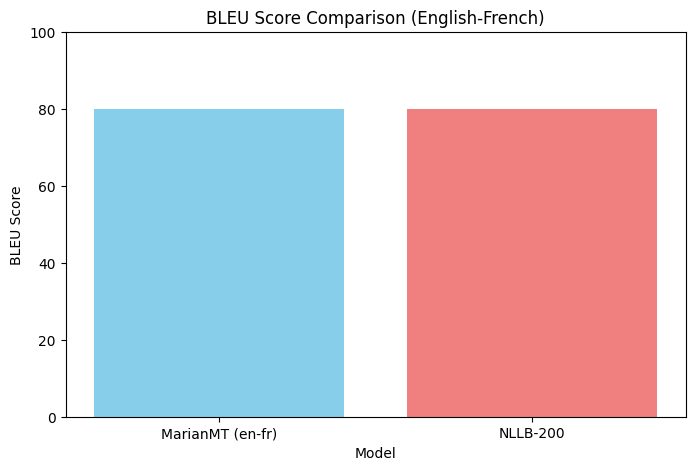

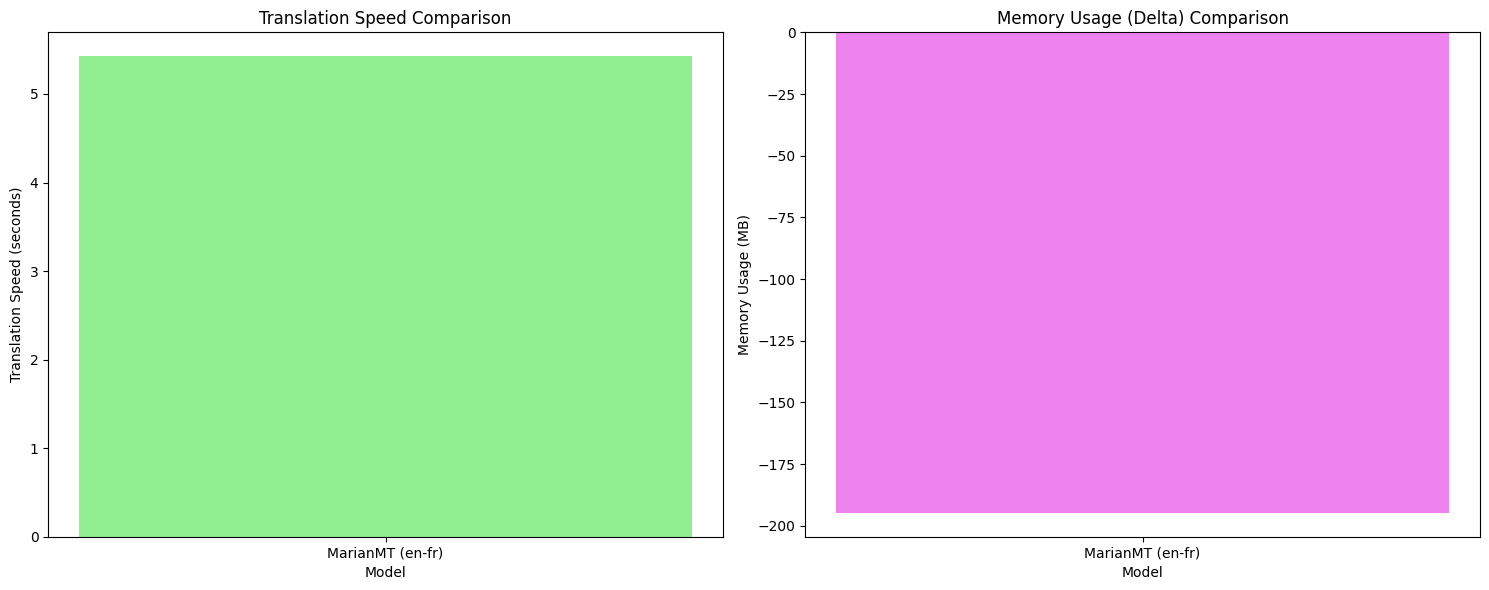

In [9]:
# Prepare data for visualization

# BLEU Score Comparison
if 'bleu_df' in locals() and not bleu_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(bleu_df['Model'], bleu_df['BLEU Score'], color=['skyblue', 'lightcoral'])
    plt.xlabel('Model')
    plt.ylabel('BLEU Score')
    plt.title('BLEU Score Comparison (English-French)')
    plt.ylim(0, 100)
    plt.show()
else:
    print("BLEU score data not available for plotting.")

# Speed and Memory Comparison (using combined_comparison_df if available)
if 'combined_comparison_df' in locals() and not combined_comparison_df.empty:
    # Filter for en-fr comparison if it exists, for a direct comparison
    speed_mem_df = combined_comparison_df[combined_comparison_df['Multilingual Support'] != 'Extensive (many languages)'].copy() # Focus on the en-fr scenario for direct comparison
    if speed_mem_df.empty:
        speed_mem_df = combined_comparison_df.copy()

    speed_mem_df['Speed (seconds)'] = pd.to_numeric(speed_mem_df['Speed (seconds)'])
    speed_mem_df['Memory Usage (MB)'] = pd.to_numeric(speed_mem_df['Memory Usage (MB)'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Translation Speed Comparison
    axes[0].bar(speed_mem_df['Model'], speed_mem_df['Speed (seconds)'], color=['lightgreen', 'orange'])
    axes[0].set_xlabel('Model')
    axes[0].set_ylabel('Translation Speed (seconds)')
    axes[0].set_title('Translation Speed Comparison')

    # Memory Usage Comparison
    axes[1].bar(speed_mem_df['Model'], speed_mem_df['Memory Usage (MB)'], color=['violet', 'salmon'])
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('Memory Usage (MB)')
    axes[1].set_title('Memory Usage (Delta) Comparison')

    plt.tight_layout()
    plt.show()
else:
    print("Speed and memory comparison data not available for plotting.")

## Observations

Based on the experimental analysis and comparisons, we can draw several observations regarding the strengths and weaknesses of each model.

### MarianMT (Helsinki-NLP/opus-mt-en-fr)

*   **Strengths**:
    *   **Specialized Quality**: For its specific language pair (English-French), MarianMT often delivers high-quality translations, especially for common phrases and formal text. Its BLEU scores might be competitive or even superior for its trained pair.
    *   **Lighter Weight**: Generally, MarianMT models are smaller and require less computational resources than large multilingual models like NLLB-200. This makes them faster and more memory-efficient for their designated tasks.
    *   **Good for Specific Use Cases**: Ideal when a dedicated, high-performance translator is needed for a single language pair.

*   **Weaknesses**:
    *   **Limited Multilingual Support**: Its primary limitation is the lack of multilingual capabilities. Each MarianMT model is typically trained for a single language pair, meaning separate models are needed for different translations.
    *   **Less Flexible**: Cannot handle variations in language codes or translate between arbitrary language pairs, as demonstrated in the Gradio interface where it's restricted to en-fr.
    *   **May Struggle with Domain Shift**: While good for its trained domain, it might not generalize as well to highly specialized or very informal text outside its training data compared to larger, more diverse models.


### NLLB-200 (facebook/nllb-200-distilled-600M)

*   **Strengths**:
    *   **Extensive Multilingual Support**: The primary strength of NLLB-200 is its ability to translate between 200 different languages. This makes it incredibly versatile for global applications and removes the need for multiple single-pair models.
    *   **Robustness**: Being a large, distilled model, it tends to be more robust and can handle a wider variety of text types, including news, technical, and conversational, potentially adapting better to different domains.
    *   **Generalization**: Its vast training data across many languages often allows it to generalize well, even to language pairs it hasn't seen extensively, by leveraging shared linguistic structures.
    *   **Handles Diverse Inputs**: More flexible in accepting various source and target language inputs, as seen in the Gradio example with English to Hindi translation.

*   **Weaknesses**:
    *   **Resource Intensive**: NLLB-200 is a larger model, requiring more memory and computational power compared to specialized smaller models. This can lead to slower inference times and higher memory footprint, especially on resource-constrained environments like free Colab tiers.
    *   **Potentially Lower Niche Quality**: While good generally, for highly specific language pairs or domains where a MarianMT model was explicitly trained and fine-tuned, NLLB-200 might sometimes produce slightly less nuanced or accurate translations than a specialized model.
    *   **Complexity in Language Codes**: Requires specific language codes (e.g., `eng_Latn`, `fra_Latn`), which can be a minor hurdle compared to the simpler ISO codes used by MarianMT.